# Episcanner — Análises Epidemiológicas

Notebook organizado para:
- carregamento e preparação dos dados;
- análise exploratória;
- processamento espacial/temporal;
- modelagem e inferência;
- visualizações;
- geração de métricas e previsões.


## 1. Importação de bibliotecas

In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
from scipy import stats
import matplotlib.pyplot as plt 
import matplotlib.gridspec as gridspec

## 4. Análises e processamento

In [2]:
el_nino_2_sem = [2014, 2015, 2018, 2023]
el_nino =   [2015, 2016, 2019, 2024]
neutros_2_sem = [2012, 2013, 2019, 2024]
neutros = [2013, 2014, 2020, 2025]
la_nina = [2011,2012, 2017, 2018,2021,2022,2023]


In [3]:
df_map = pd.read_csv('data/map_regional_health.csv')

df_map.head()

,macroregion_code,macroregion_name,uf_code,uf,uf_name,macroregional_geocode,macroregional_name,regional_geocode,regional_name,geocode,geocode_name
0,1,Norte,12,AC,Acre,1201,MACRO UNICA - AC,12002,BAIXO ACRE E PURUS,1200013,AC - ACRELANDIA
1,1,Norte,12,AC,Acre,1201,MACRO UNICA - AC,12001,ALTO ACRE,1200054,AC - ASSIS BRASIL
2,1,Norte,12,AC,Acre,1201,MACRO UNICA - AC,12001,ALTO ACRE,1200104,AC - BRASILEIA
3,1,Norte,12,AC,Acre,1201,MACRO UNICA - AC,12002,BAIXO ACRE E PURUS,1200138,AC - BUJARI
4,1,Norte,12,AC,Acre,1201,MACRO UNICA - AC,12002,BAIXO ACRE E PURUS,1200179,AC - CAPIXABA


In [4]:
df_pop = pd.read_csv('data/datasus_population_2001_2025.csv.gz')
df_pop = df_pop.loc[df_pop.year == 2022]       
df_pop

,geocode,year,population
116970,3540002,2022,20623
116971,3540101,2022,3473
116972,3540408,2022,4217
116973,3540259,2022,4208
116974,3540309,2022,2439
...,...,...,...
122535,2902252,2022,10655
122536,2902203,2022,10241
122537,2902104,2022,50716
122538,2902054,2022,11955


Dados de dengue - a partir de 2011: 

In [5]:
df_dengue = pd.read_parquet('data/episcanner_dengue.parquet')

#df_dengue = df_dengue.loc[df_dengue.year >= 2019]

#print(df_dengue.year.unique())
#print(df_dengue['year'].value_counts())


df_dengue = df_dengue.merge(df_map[['geocode', 'macroregion_name', 'uf']], on = 'geocode')

df_dengue = df_dengue.merge(df_pop[['geocode', 'population']], on = 'geocode')

df_dengue.loc[:, 'cenario'] = 'Outros'

df_dengue.loc[df_dengue.year.isin(el_nino), 'cenario'] = 'El niño' 
#df_dengue.loc[df_dengue.year.isin(neutros), 'cenario'] = 'Outros' 

df_dengue['new_v'] = (
    np.where(
        df_dengue['ep_ini'].astype(str).str[-2:].astype(int) > 45,
        df_dengue['ep_ini'].astype(str).str[-2:].astype(int) - 45,
        df_dengue['ep_ini'].astype(str).str[-2:].astype(int) + 7
    )
)

#df_dengue["thr_regiao"] = (
#    df_dengue
#    .groupby("macroregion_name")["sum_res"]
#    .transform(lambda x: np.percentile(x, 95))
#)

#df_dengue = df_dengue.loc[
#    df_dengue["sum_res"] < df_dengue["thr_regiao"]
#]

df_dengue = df_dengue.dropna()

df_dengue = df_dengue.loc[df_dengue.population >= 100000]

df_dengue.head()

,disease,CID10,year,geocode,muni_name,peak_week,beta,gamma,R0,total_cases,alpha,sum_res,ep_ini,ep_end,ep_dur,macroregion_name,uf,population,cenario,new_v
7,dengue,A90,2011,2700300,Arapiraca,23.055816,0.425573,0.30,1.418575,1148.236397,0.295067,1.709683,201046,201136,42,Nordeste,AL,240406,Outros,1
32,dengue,A90,2012,2704302,Maceió,30.041860,0.439194,0.30,1.463980,14632.770027,0.316931,1.100189,201146,201241,47,Nordeste,AL,990368,Outros,1
45,dengue,A90,2012,2700300,Arapiraca,20.616505,0.453764,0.30,1.512548,4020.802099,0.338864,1.266841,201146,201230,36,Nordeste,AL,240406,Outros,1
62,dengue,A90,2013,2704302,Maceió,28.851176,0.428748,0.33,1.299238,4691.750027,0.230318,0.984442,201246,201344,50,Nordeste,AL,990368,Outros,1
72,dengue,A90,2013,2700300,Arapiraca,34.196589,0.440276,0.30,1.467586,3689.503494,0.318609,1.599060,201251,201344,45,Nordeste,AL,240406,Outros,6


In [6]:
df_dengue.cenario.value_counts()

cenario
Outros     2669
El niño    1177
Name: count, dtype: int64

In [7]:
df_dengue.year.unique()

array([2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021,
       2022, 2023, 2024, 2025])

Dados de chikungunya - a partir de 2016: 

In [8]:
df_chik = pd.read_parquet('data/episcanner_chik.parquet')

df_chik = df_chik.merge(df_map[['geocode', 'macroregion_name', 'uf']], on = 'geocode')

df_chik = df_chik.merge(df_pop[['geocode', 'population']], on = 'geocode')

df_chik.loc[:, 'cenario'] = "Outros"

df_chik.loc[df_chik.year.isin(el_nino), 'cenario'] = 'El niño' 
#df_chik.loc[df_chik.year.isin(neutros), 'cenario'] = 'Neutro' 

df_chik['new_v'] = (
    np.where(
        df_chik['ep_ini'].astype(str).str[-2:].astype(int) > 45,
        df_chik['ep_ini'].astype(str).str[-2:].astype(int) - 45,
        df_chik['ep_ini'].astype(str).str[-2:].astype(int) + 7
    )
)

df_chik = df_chik.dropna()

df_chik = df_chik.loc[df_chik.population >= 100000]

df_chik.head()

,disease,CID10,year,geocode,muni_name,peak_week,beta,gamma,R0,total_cases,alpha,sum_res,ep_ini,ep_end,ep_dur,macroregion_name,uf,population,cenario,new_v
16,chik,A92.0,2016,2700300,Arapiraca,32.347838,0.485015,0.300000,1.616717,1099.669245,0.381462,1.020054,201604,201640,36,Nordeste,AL,240406,El niño,11
19,chik,A92.0,2016,2704302,Maceió,29.181185,0.501774,0.300000,1.672580,7535.716893,0.402121,0.649263,201603,201636,33,Nordeste,AL,990368,El niño,10
37,chik,A92.0,2018,2704302,Maceió,31.585402,0.409936,0.329974,1.242327,175.919857,0.195059,1.519167,201746,201844,50,Nordeste,AL,990368,Outros,1
42,chik,A92.0,2019,2704302,Maceió,35.000000,0.446323,0.300697,1.484293,490.031453,0.326279,0.789208,201902,201945,43,Nordeste,AL,990368,El niño,9
43,chik,A92.0,2019,2700300,Arapiraca,27.375626,0.571280,0.327973,1.741849,405.843461,0.425897,0.651940,201905,201933,28,Nordeste,AL,240406,El niño,12


## 5. Visualizações

In [ ]:
doenca = 'Chikungunya'

if doenca == 'Dengue':

    df_pars = df_dengue

elif doenca == 'Chikungunya': 

    df_pars = df_chik


In [10]:
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.titlesize': 16
})

In [11]:
def plot_violin_by_region(
    df,
    column,
    group_col,
    group_a,
    group_b,
    title='',
    ylabel='',
    xlabel='',
    filename=None,
    palette=None,
    add_median_line=True,
):
    """
    Cria violinplots por macroregião comparando dois grupos.

    Parameters
    ----------
    df : pd.DataFrame
    column : str
        Coluna numérica a ser analisada.
    group_col : str
        Coluna que define os grupos.
    group_a, group_b :
        Valores dos dois grupos comparados.
    title : str
    ylabel : str
    xlabel : str
    filename : str or None
    palette : list or None
    add_median_line : bool
    """

    regions = ['Sul', 'Sudeste', 'Centro-Oeste', 'Norte', 'Nordeste']

    fig = plt.figure(figsize=(16, 8))
    gs = gridspec.GridSpec(2, 6, figure=fig)

    axes = [
        fig.add_subplot(gs[0, 0:2]),
        fig.add_subplot(gs[0, 2:4]),
        fig.add_subplot(gs[0, 4:6]),
        fig.add_subplot(gs[1, 1:3]),
        fig.add_subplot(gs[1, 3:5]),
    ]

    for region, ax in zip(regions, axes):

        df_ = df.loc[df.macroregion_name == region]

        values_a = df_.loc[df_[group_col] == group_a, column].values
        values_b = df_.loc[df_[group_col] == group_b, column].values

        n_a = len(values_a)
        n_b = len(values_b)

        p = stats.ttest_ind(
            values_a,
            values_b,
            alternative='two-sided'
        ).pvalue

        label = '(p < 0.01)' if p < 0.01 else '(p > 0.01)'

        sns.violinplot(
            data=df_,
            x=group_col,
            y=column,
            hue=group_col,
            legend=False,
            palette=palette,
            ax=ax
        )

        if add_median_line:
            ax.axhline(
                np.median(values_b),
                color='orange',
                zorder=2,
                label=f'Mediana - {group_b}'
            )
            ax.legend()

        ax.set_title(f'{region} {label}', fontsize=16)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.grid(axis='y')
        
        ax.set_xticks([0, 1])
        ax.set_xticklabels([
            f'{group_a}\n(n={n_a})',
            f'{group_b}\n(n={n_b})'
        ])

        if column == 'total_cases': 
            ax.set_yscale('log')

    plt.suptitle(title)
    plt.tight_layout()

    if filename is not None:
        plt.savefig(filename, dpi=200, bbox_inches='tight')

    plt.show()

Semana de pico: 

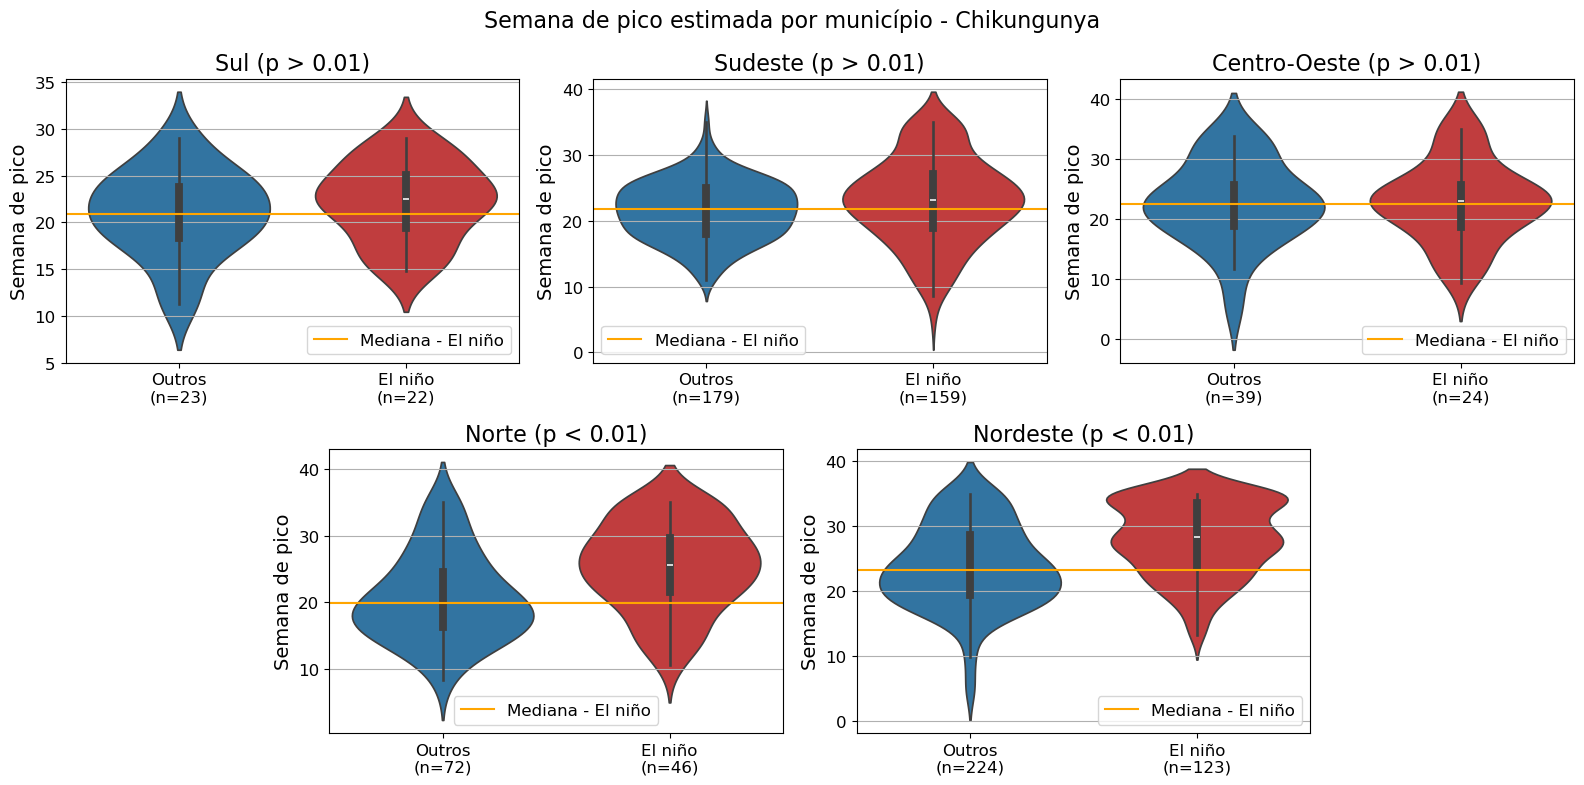

In [12]:
plot_violin_by_region(
    df=df_pars,
    column='peak_week',
    group_col='cenario',
    group_a='Outros',
    group_b='El niño',
    title=f'Semana de pico estimada por município - {doenca}',
    ylabel='Semana de pico',
    filename=f'figures/semana_pico_{doenca}.png',
    palette=['tab:blue', 'tab:red']
)

R0: 

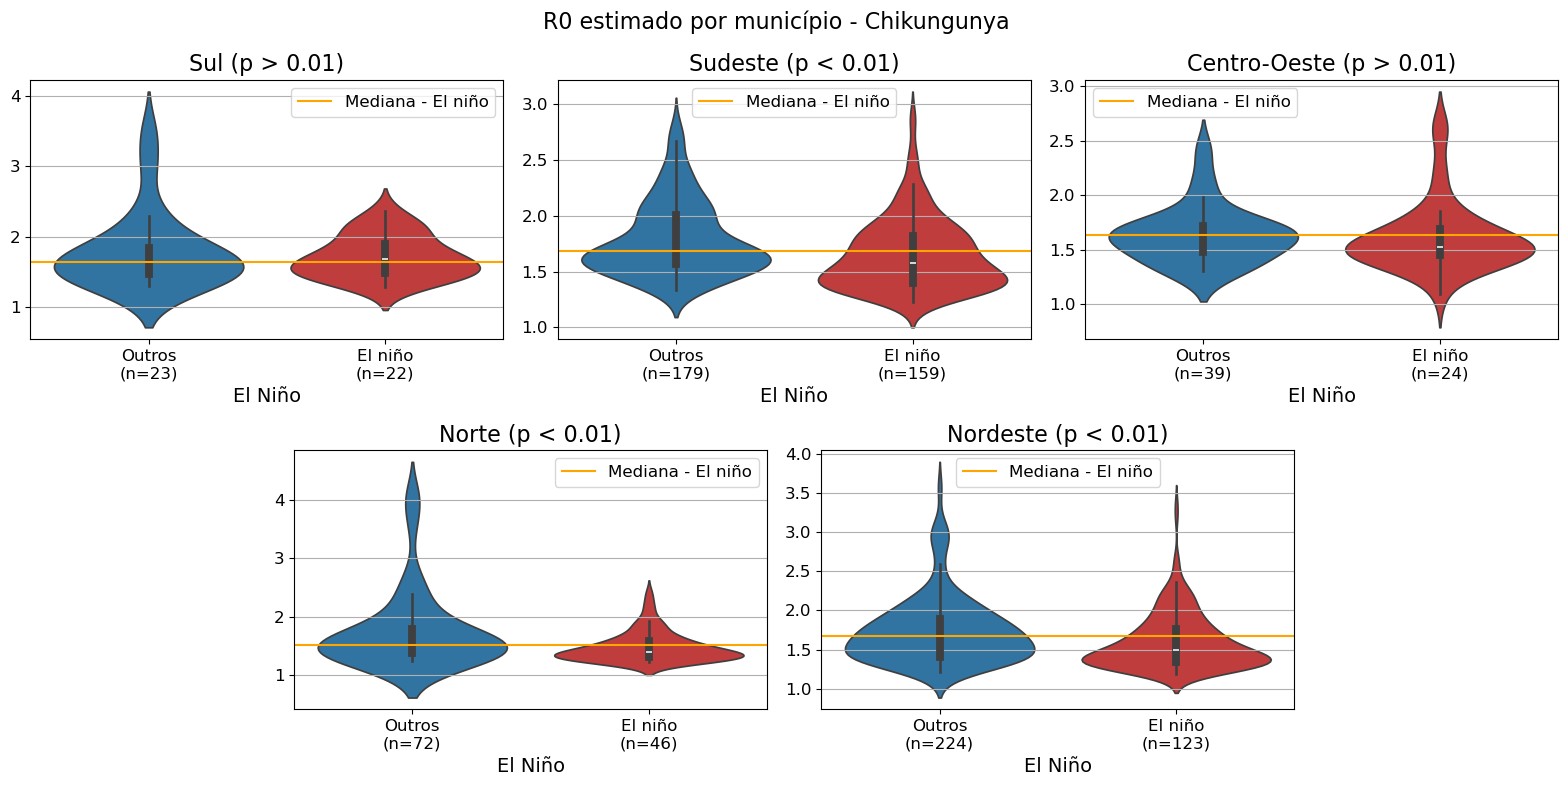

In [13]:
plot_violin_by_region(
    df=df_pars,
    column='R0',
    group_col='cenario',
    group_a='Outros',
    group_b='El niño',
    title=f'R0 estimado por município - {doenca}',
    xlabel='El Niño',
    filename=f'figures/R0_{doenca}.png',
    palette=['tab:blue', 'tab:red']
)

Total cases: 

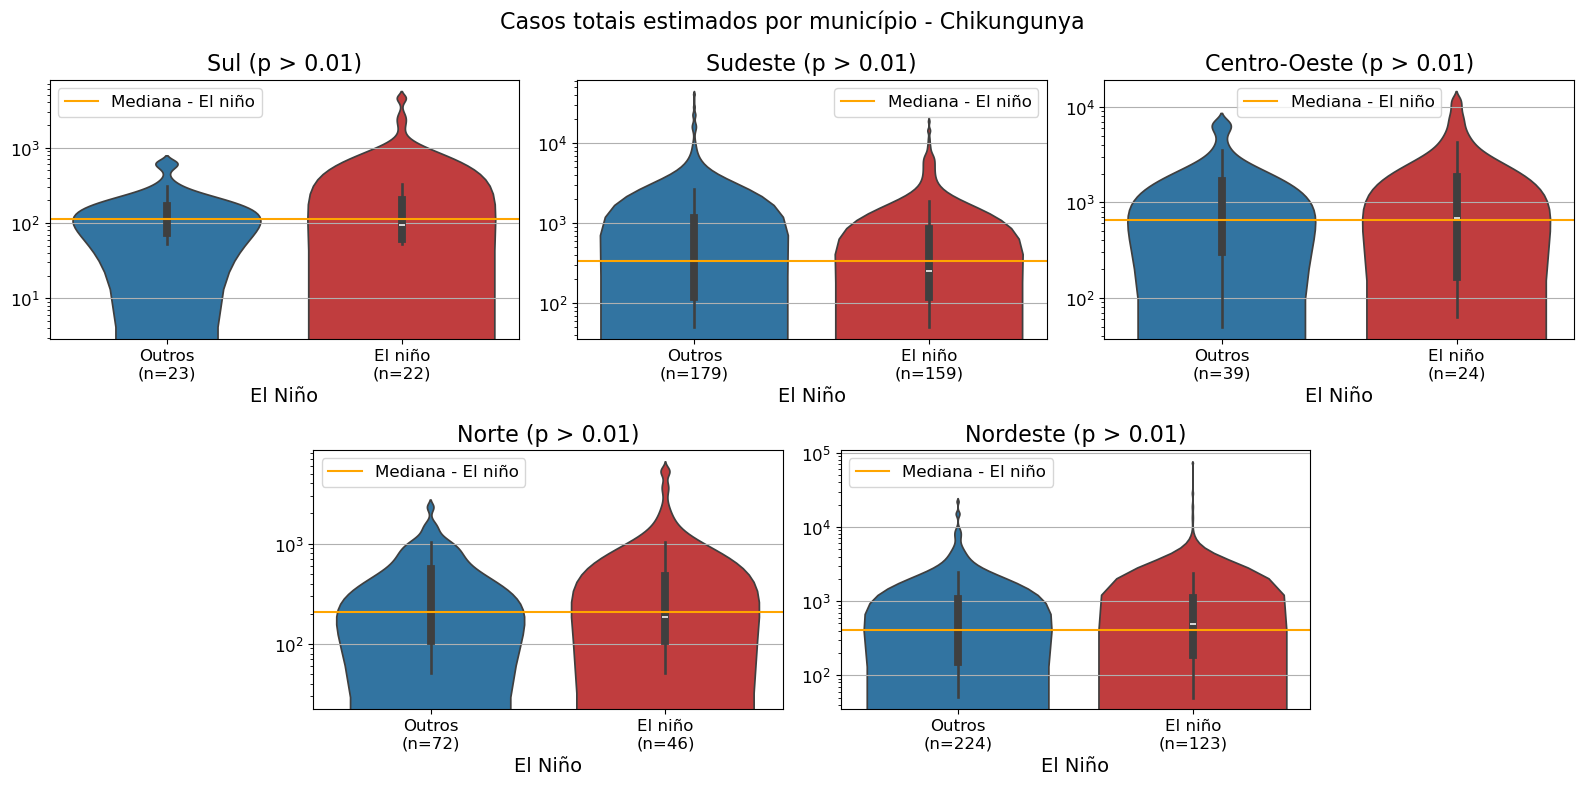

In [14]:
plot_violin_by_region(
    df=df_pars,
    column='total_cases',
    group_col='cenario',
    group_a='Outros',
    group_b='El niño',
    title=f'Casos totais estimados por município - {doenca}',
    xlabel='El Niño',
    filename=f'figures/total_cases_{doenca}.png',
    palette=['tab:blue', 'tab:red']
)

Duração da epidemia: 

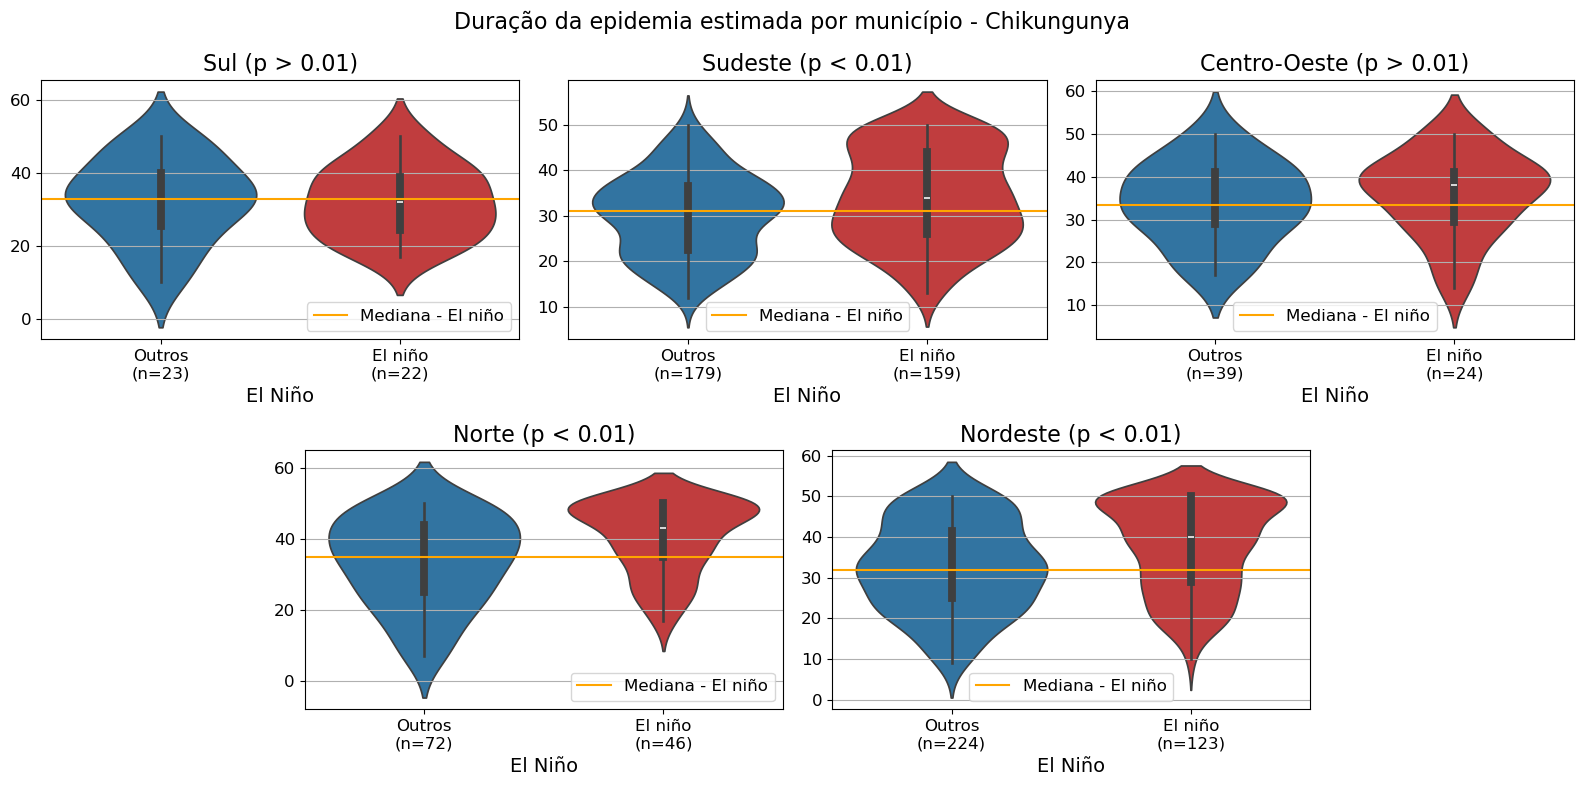

In [15]:
plot_violin_by_region(
    df=df_pars,
    column='ep_dur',
    group_col='cenario',
    group_a='Outros',
    group_b='El niño',
    title=f'Duração da epidemia estimada por município - {doenca}',
    xlabel='El Niño',
    filename=f'figures/ep_dur_{doenca}.png',
    palette=['tab:blue', 'tab:red']
)

## Gráficos por estado: 

In [16]:
df_dengue.columns

Index(['disease', 'CID10', 'year', 'geocode', 'muni_name', 'peak_week', 'beta',
       'gamma', 'R0', 'total_cases', 'alpha', 'sum_res', 'ep_ini', 'ep_end',
       'ep_dur', 'macroregion_name', 'uf', 'population', 'cenario', 'new_v'],
      dtype='str')

In [17]:
def plot_violin_by_state(ax, 
    df,
    state,
    column,
    group_col,
    group_a,
    group_b,
    ylabel='',
    xlabel='',
    palette=None,
    add_median_line=True,
):
    """
    Cria violinplots por macroregião comparando dois grupos.

    Parameters
    ----------
    df : pd.DataFrame
    column : str
        Coluna numérica a ser analisada.
    group_col : str
        Coluna que define os grupos.
    group_a, group_b :
        Valores dos dois grupos comparados.
    title : str
    ylabel : str
    xlabel : str
    filename : str or None
    palette : list or None
    add_median_line : bool
    """


    df_ = df.loc[df.uf == state]

    values_a = df_.loc[df_[group_col] == group_a, column].values
    values_b = df_.loc[df_[group_col] == group_b, column].values

    n_a = len(values_a)
    n_b = len(values_b)

    p = stats.ttest_ind(
            values_a,
            values_b,
            alternative='two-sided'
        ).pvalue

    label = '(p < 0.01)' if p < 0.01 else '(p > 0.01)'

    sns.violinplot(
            data=df_,
            x=group_col,
            y=column,
            hue=group_col,
            legend=False,
            palette=palette,
            ax=ax
        )

    if add_median_line:
            ax.axhline(
                np.median(values_b),
                color='orange',
                zorder=2,
                label=f'Mediana - {group_b}'
            )
            ax.legend()

    ax.set_title(f'{state} {label}', fontsize=16)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(axis='y')
        
    ax.set_xticks([0, 1])
    
    ax.set_xticklabels([
            f'{group_a}\n(n={n_a})',
            f'{group_b}\n(n={n_b})'
        ])

    if column == 'total_cases': 
        ax.set_yscale('log')



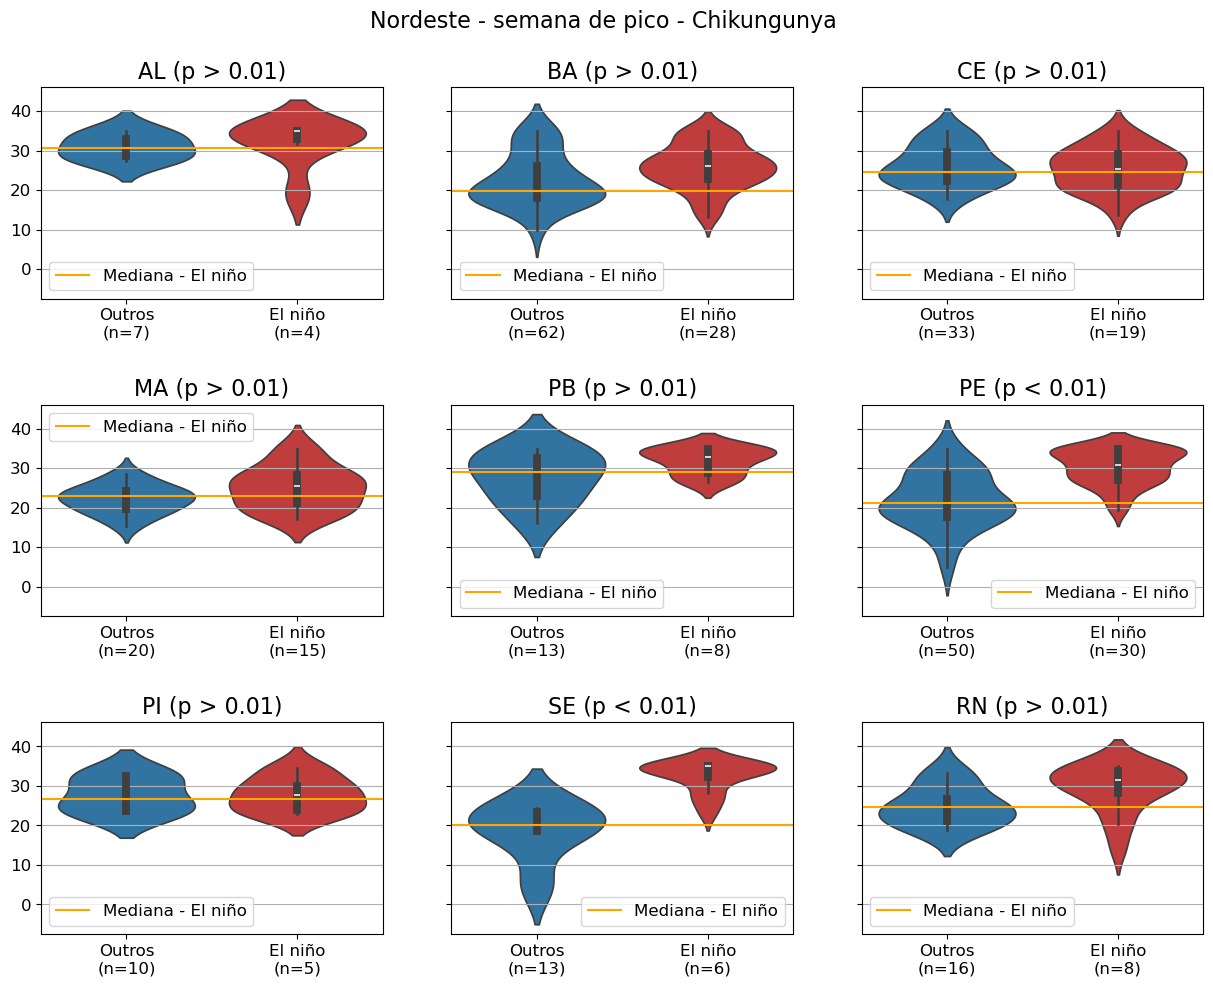

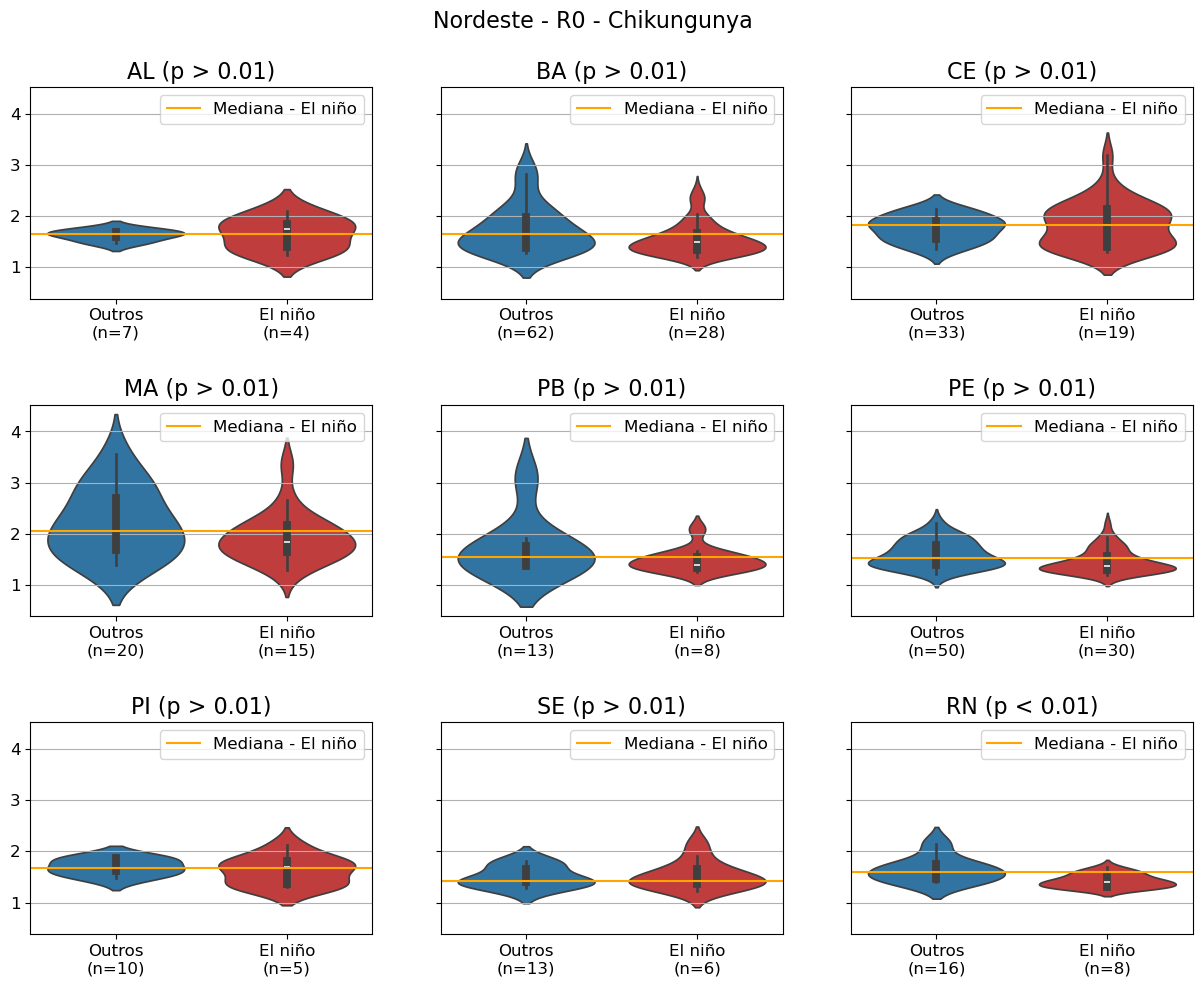

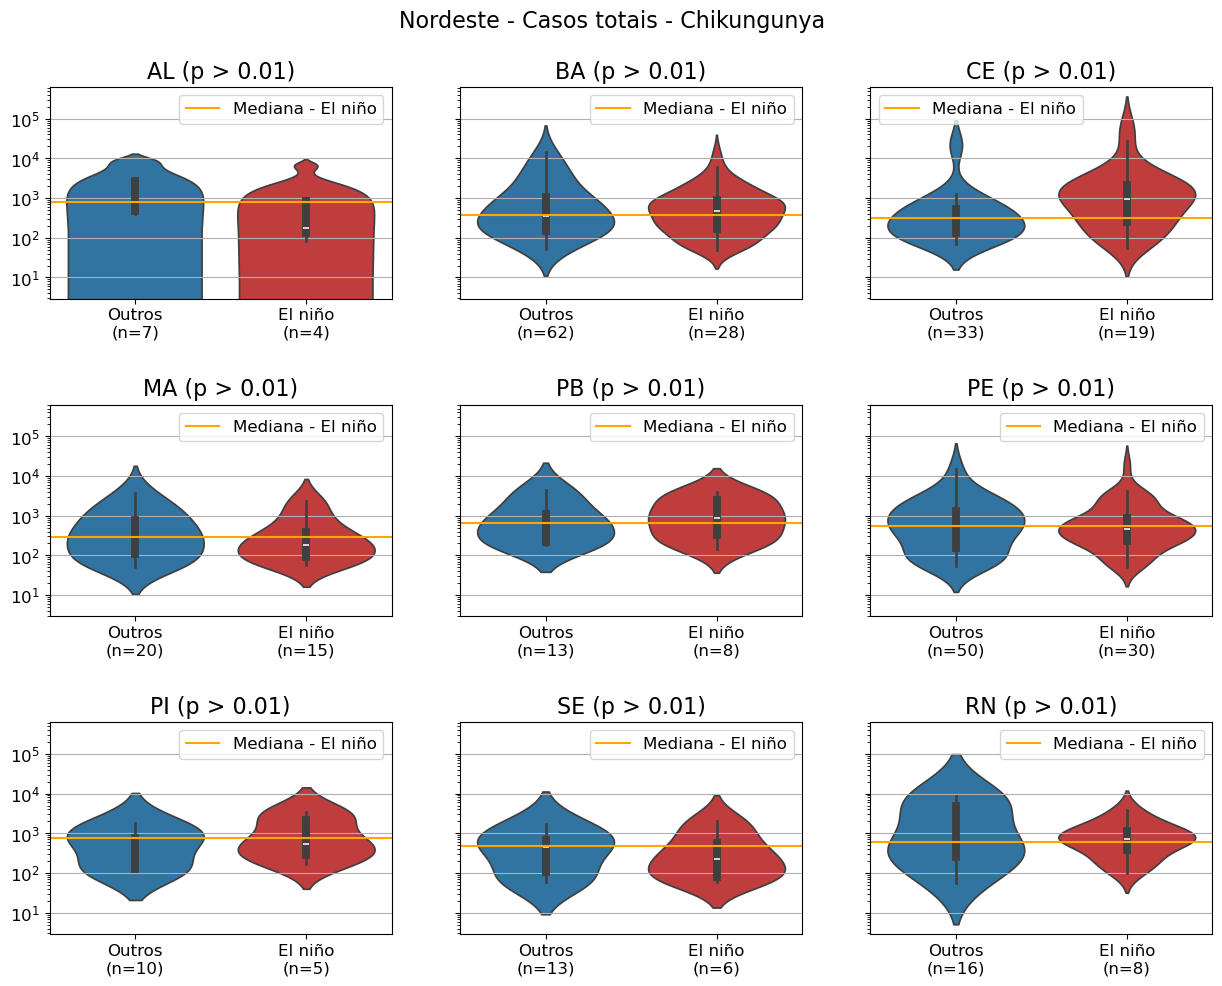

In [18]:
state = ['AL', 'BA', 'CE','MA', 'PB', 'PE', 'PI', 'SE', 'RN']

for col in ['peak_week', 'R0', 'total_cases']:

    if col == 'peak_week':
        label = 'semana de pico'

    elif col == 'R0': 
        label = 'R0'

    elif col == 'total_cases': 
        label = 'Casos totais'

    _, ax = plt.subplots(3,3, figsize = (15,11), sharey=True)

    axs = ax.ravel()

    for st, ax in zip(state, axs): 

        plot_violin_by_state(ax, 
            df_pars,
            state = st,
            column = col,
            group_col = 'cenario',
            group_a = 'Outros',
            group_b = 'El niño',
            xlabel='',
            ylabel='',
            palette=['tab:blue', 'tab:red'],
            add_median_line=True,
        )

    plt.suptitle(f'Nordeste - {label} - {doenca}', y = 0.95)
    plt.subplots_adjust(hspace = 0.5)
    plt.savefig(f'figures/nordeste_{label.lower().replace(" ", "_")}_{doenca.lower().replace(" ", "_")}.png', dpi = 300, bbox_inches ='tight')
    plt.show()

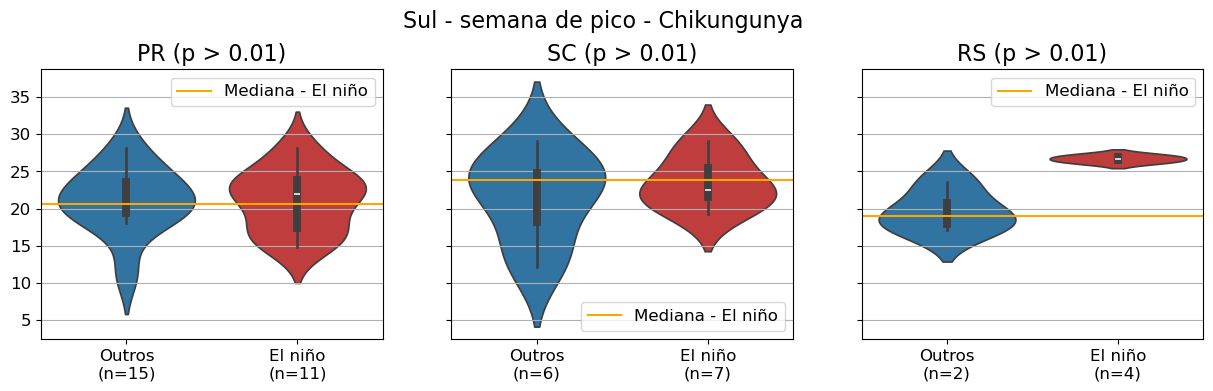

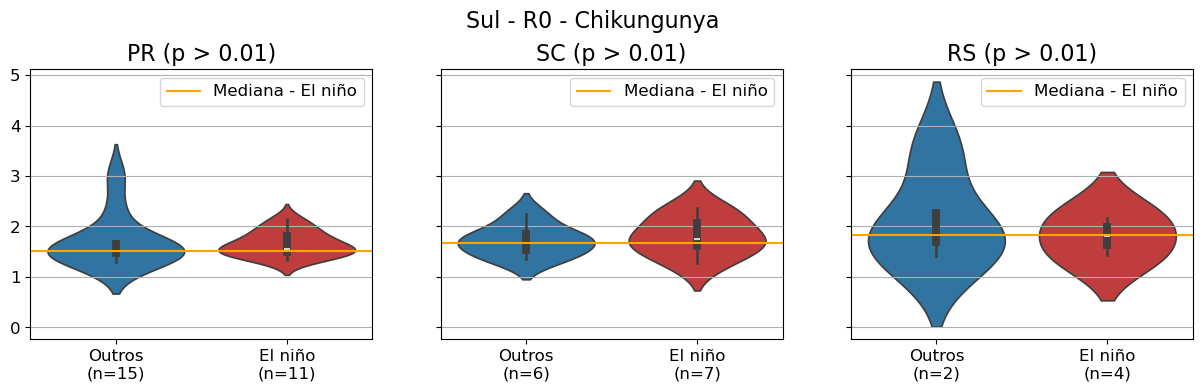

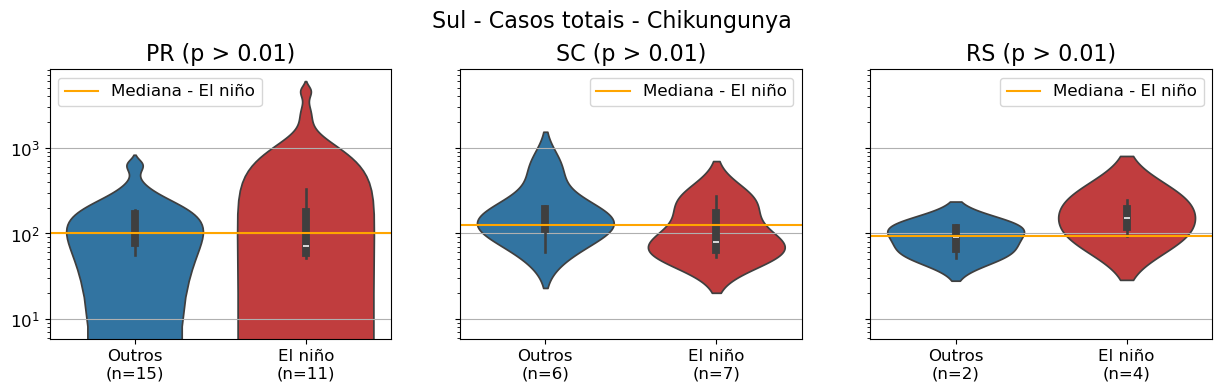

In [19]:
state = ['PR', 'SC', 'RS']

for col in ['peak_week', 'R0', 'total_cases']:

    if col == 'peak_week':
        label = 'semana de pico'

    elif col == 'R0': 
        label = 'R0'

    elif col == 'total_cases': 
        label = 'Casos totais'

    _, ax = plt.subplots(1,3, figsize = (15,3.5), sharey=True)

    axs = ax.ravel()

    for st, ax in zip(state, axs): 

        plot_violin_by_state(ax, 
            df_pars,
            state = st,
            column = col,
            group_col = 'cenario',
            group_a = 'Outros',
            group_b = 'El niño',
            xlabel='',
            ylabel='',
            palette=['tab:blue', 'tab:red'],
            add_median_line=True,
        )

    plt.suptitle(f'Sul - {label} - {doenca}', y = 1.05)
    plt.subplots_adjust(hspace = 0.5)
    plt.savefig(f'figures/sul_{label.lower().replace(" ", "_")}_{doenca.lower().replace(" ", "_")}.png', dpi = 300, bbox_inches ='tight')
    plt.show()

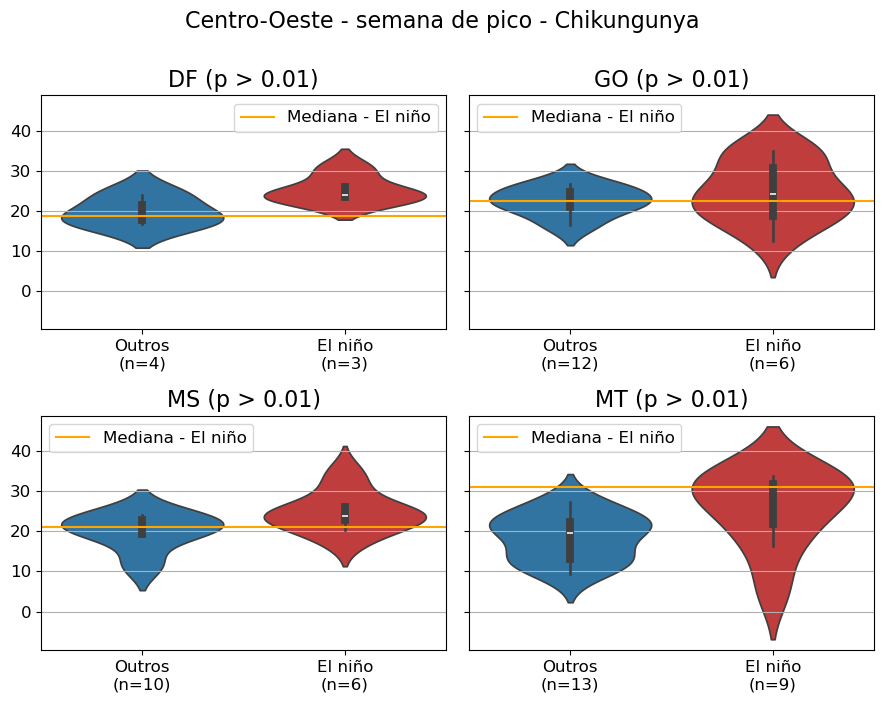

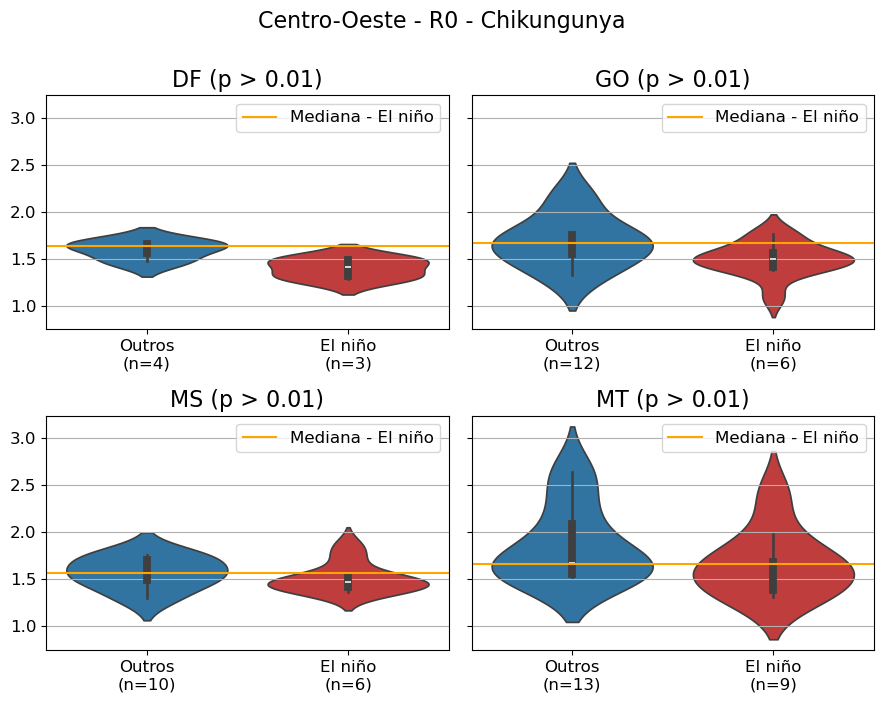

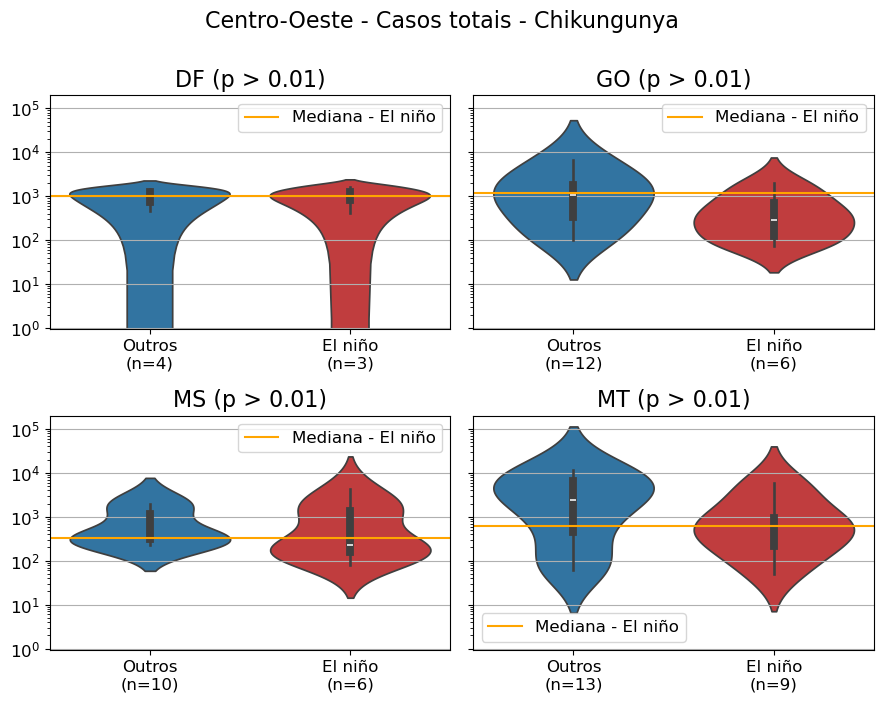

In [20]:
state = ['DF', 'GO', 'MS', 'MT']

for col in ['peak_week', 'R0', 'total_cases']:

    if col == 'peak_week':
        label = 'semana de pico'

    elif col == 'R0': 
        label = 'R0'

    elif col == 'total_cases': 
        label = 'Casos totais'

    _, ax = plt.subplots(2,2, figsize = (9,7), sharey=True)

    axs = ax.ravel()

    for st, ax in zip(state, axs): 

        plot_violin_by_state(ax, 
            df_pars,
            state = st,
            column = col,
            group_col = 'cenario',
            group_a = 'Outros',
            group_b = 'El niño',
            xlabel='',
            ylabel='',
            palette=['tab:blue', 'tab:red'],
            add_median_line=True,
        )

    plt.suptitle(f'Centro-Oeste - {label} - {doenca}', y = 1)
    plt.tight_layout()
    plt.savefig(f'figures/centro_oeste_{label.lower().replace(" ", "_")}_{doenca.lower().replace(" ", "_")}.png', dpi = 300, bbox_inches ='tight')
    plt.show()

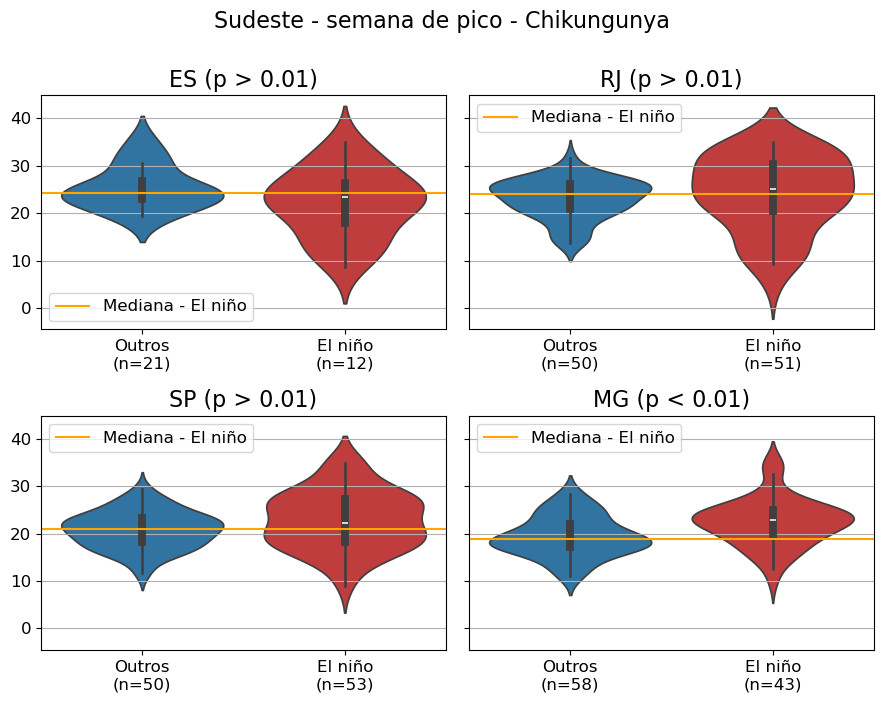

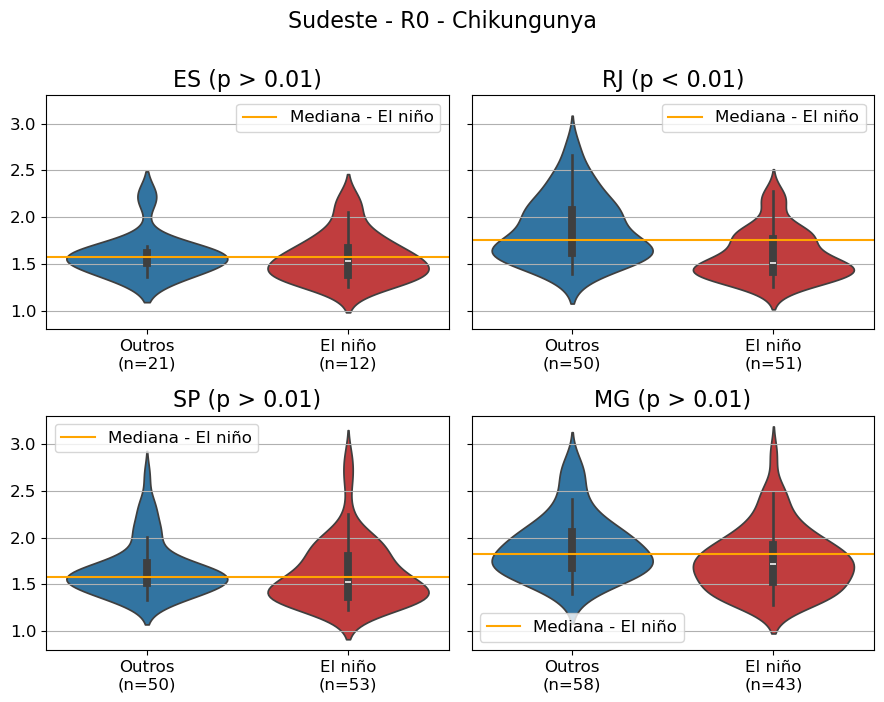

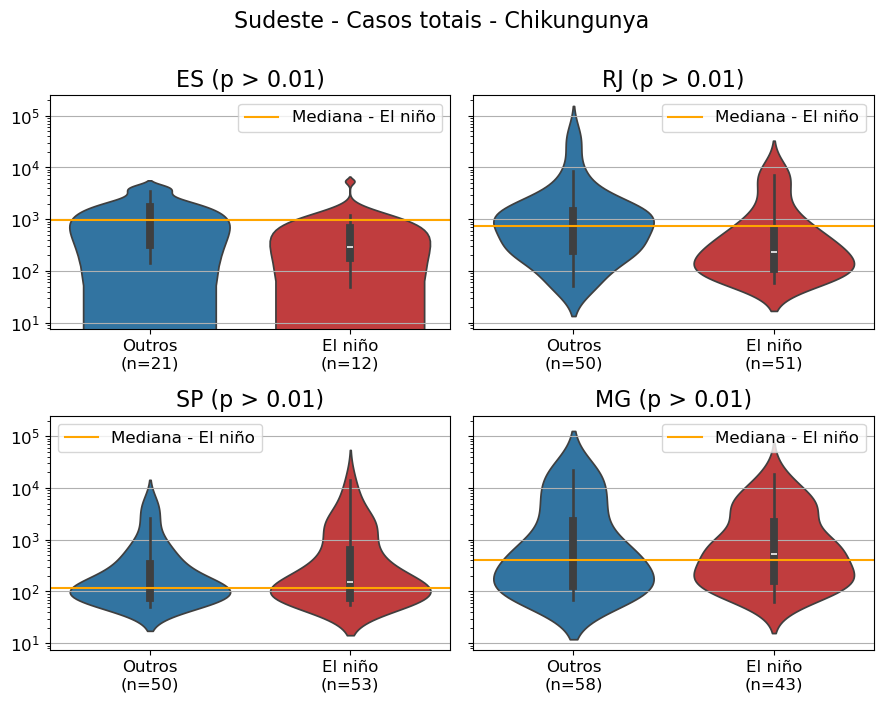

In [21]:
state = ['ES', 'RJ', 'SP', 'MG']

for col in ['peak_week', 'R0', 'total_cases']:

    if col == 'peak_week':
        label = 'semana de pico'

    elif col == 'R0': 
        label = 'R0'

    elif col == 'total_cases': 
        label = 'Casos totais'

    _, ax = plt.subplots(2,2, figsize = (9,7), sharey=True)

    axs = ax.ravel()

    for st, ax in zip(state, axs): 

        plot_violin_by_state(ax, 
            df_pars,
            state = st,
            column = col,
            group_col = 'cenario',
            group_a = 'Outros',
            group_b = 'El niño',
            xlabel='',
            ylabel='',
            palette=['tab:blue', 'tab:red'],
            add_median_line=True,
        )

    plt.suptitle(f'Sudeste - {label} - {doenca}', y = 1)
    plt.tight_layout()
    plt.savefig(f'figures/sudeste_{label.lower().replace(" ", "_")}_{doenca.lower().replace(" ", "_")}.png', dpi = 300, bbox_inches ='tight')
    plt.show()

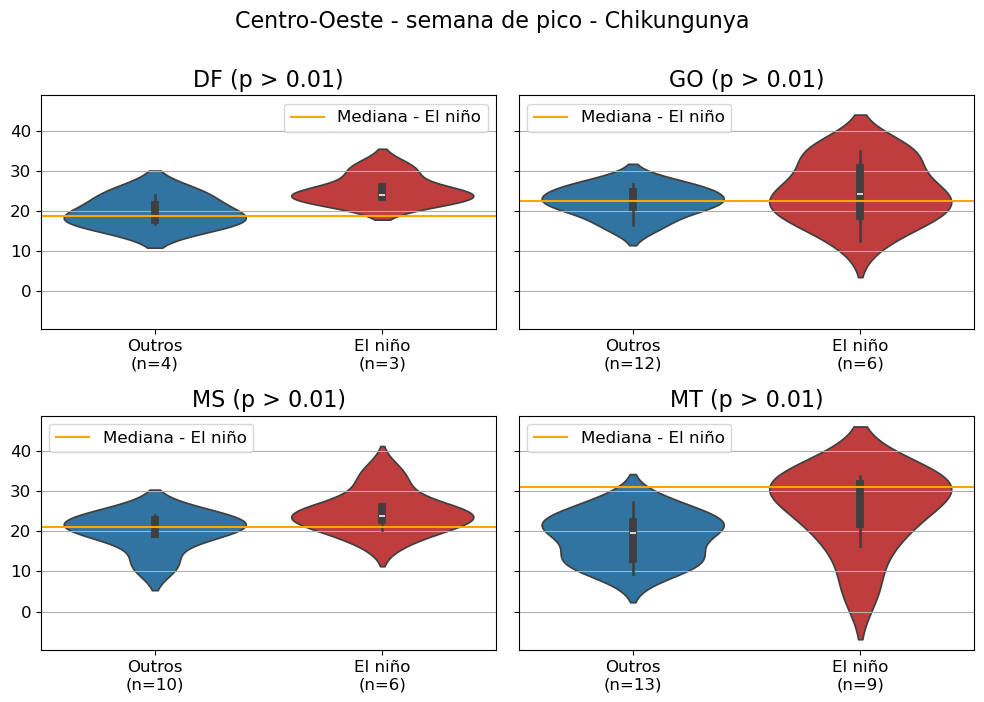

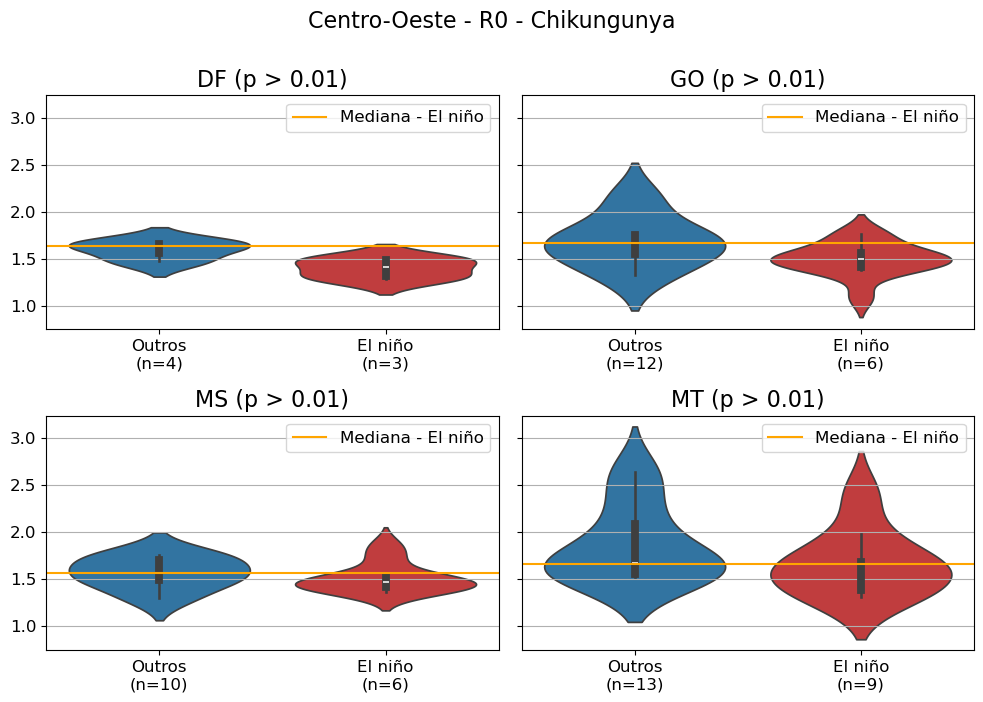

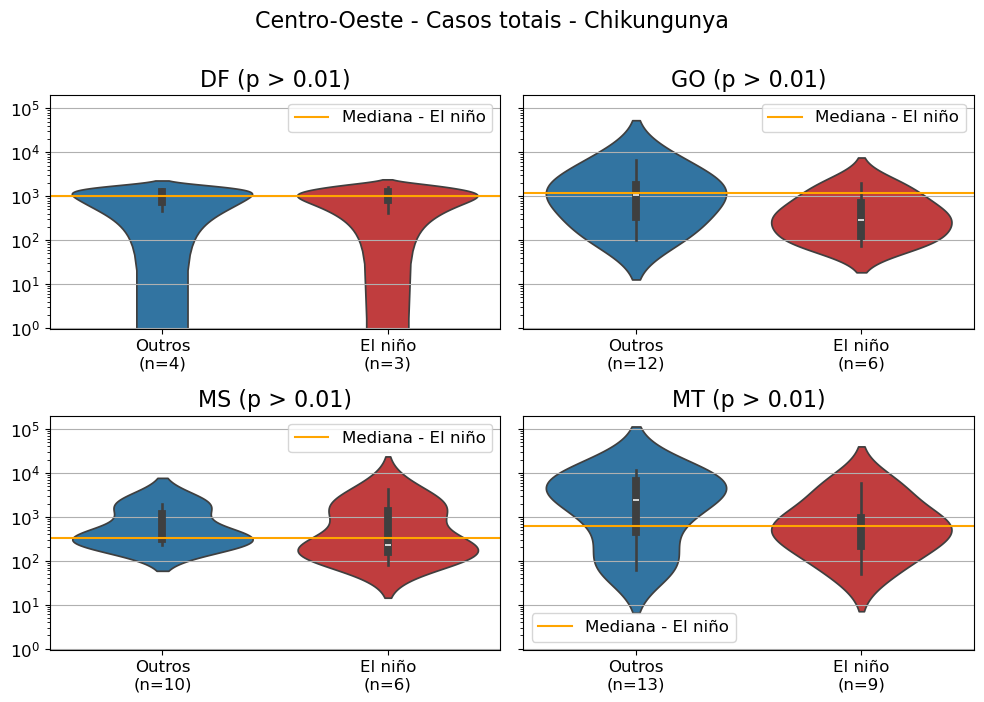

In [22]:
state = ['DF', 'GO', 'MS', 'MT']

for col in ['peak_week', 'R0', 'total_cases']:

    if col == 'peak_week':
        label = 'semana de pico'

    elif col == 'R0': 
        label = 'R0'

    elif col == 'total_cases': 
        label = 'Casos totais'

    _, ax = plt.subplots(2,2, figsize = (10,7), sharey=True)

    axs = ax.ravel()

    for st, ax in zip(state, axs): 

        plot_violin_by_state(ax, 
            df_pars,
            state = st,
            column = col,
            group_col = 'cenario',
            group_a = 'Outros',
            group_b = 'El niño',
            xlabel='',
            ylabel='',
            palette=['tab:blue', 'tab:red'],
            add_median_line=True,
        )

    plt.suptitle(f'Centro-Oeste - {label} - {doenca}', y = 1)
    plt.tight_layout()
    plt.savefig(f'figures/centro_oeste_{label.lower().replace(" ", "_")}_{doenca.lower().replace(" ", "_")}.png', dpi = 300, bbox_inches ='tight')
    plt.show()

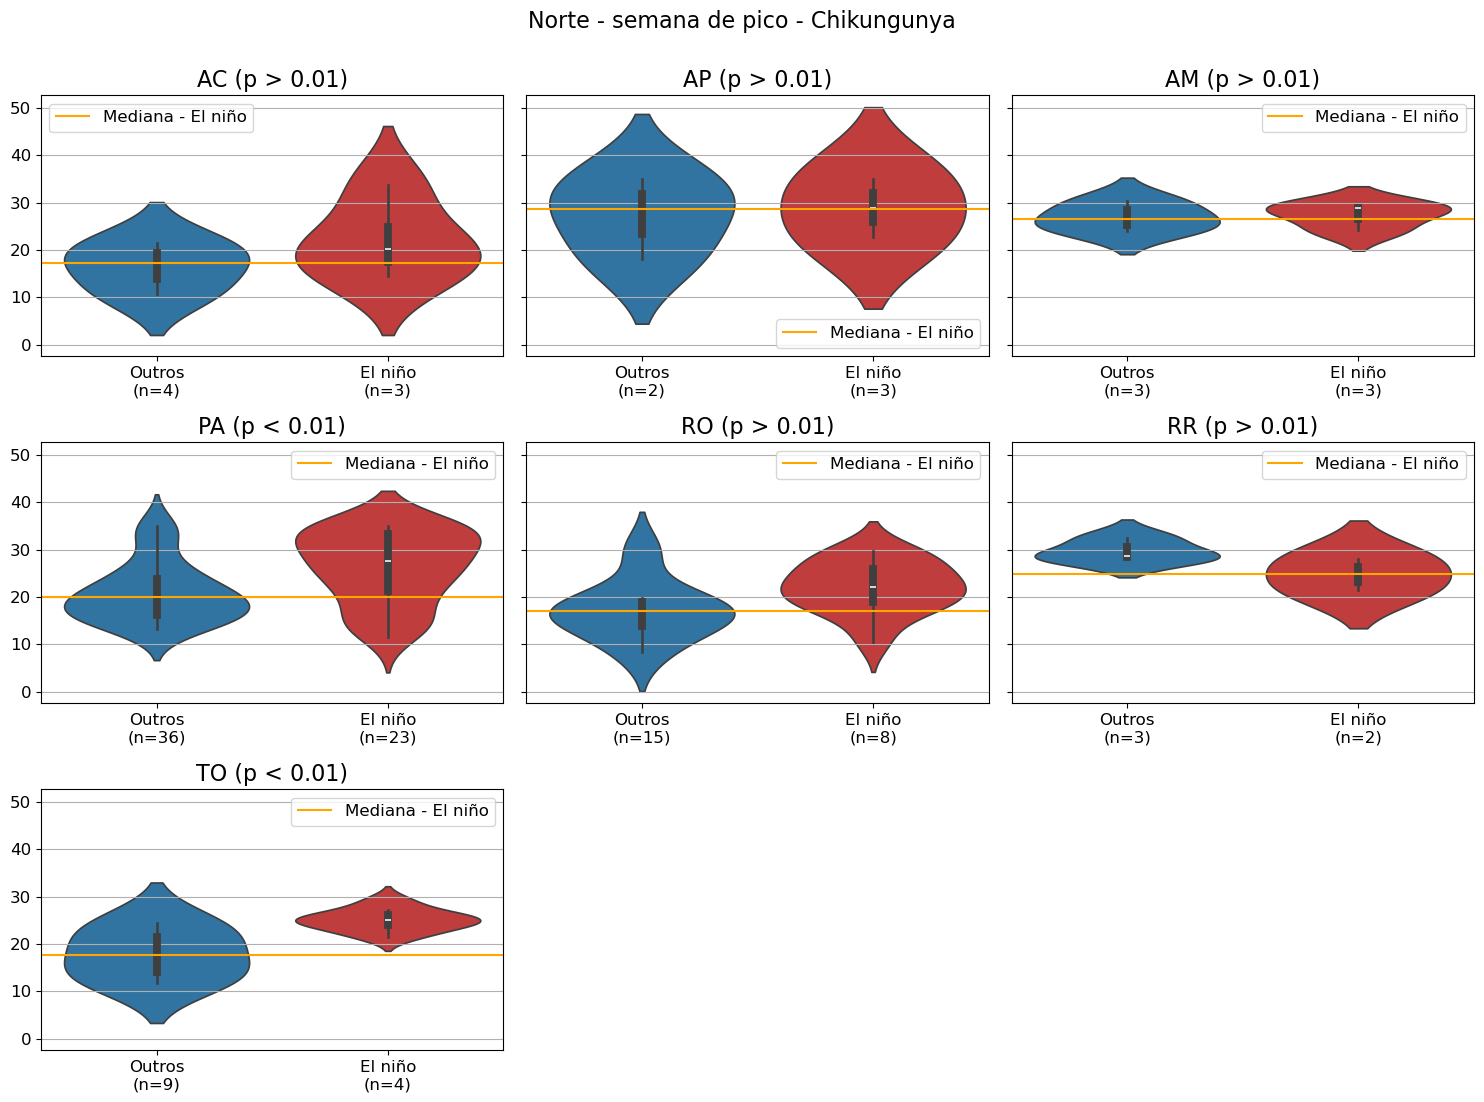

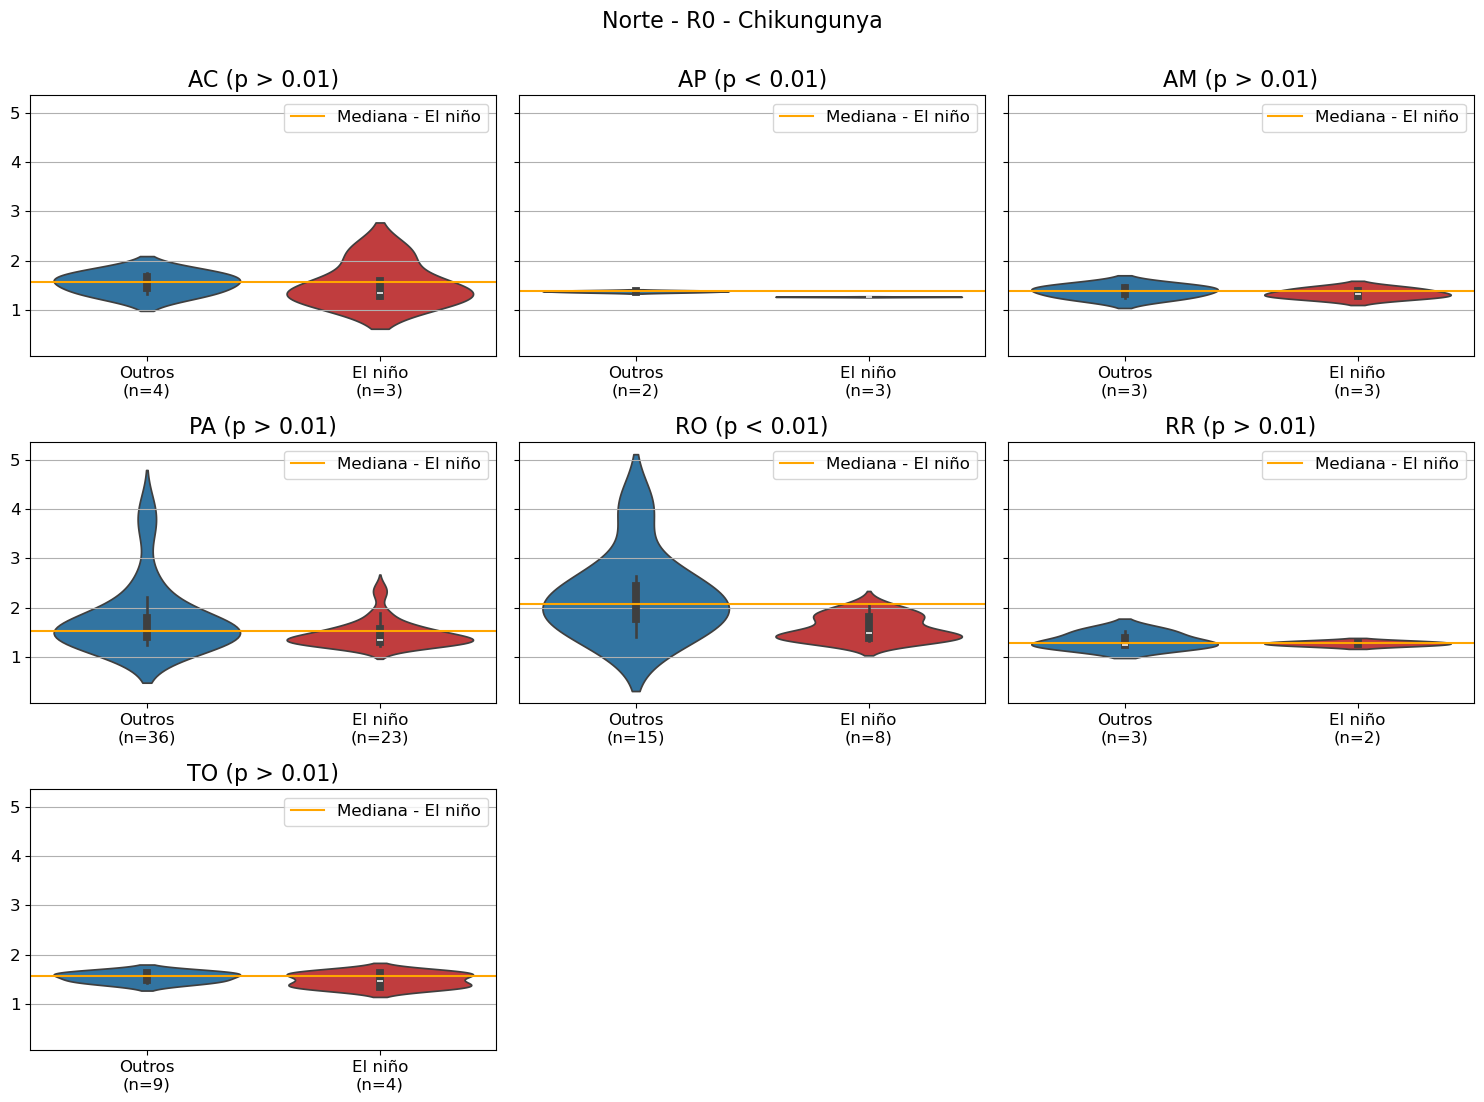

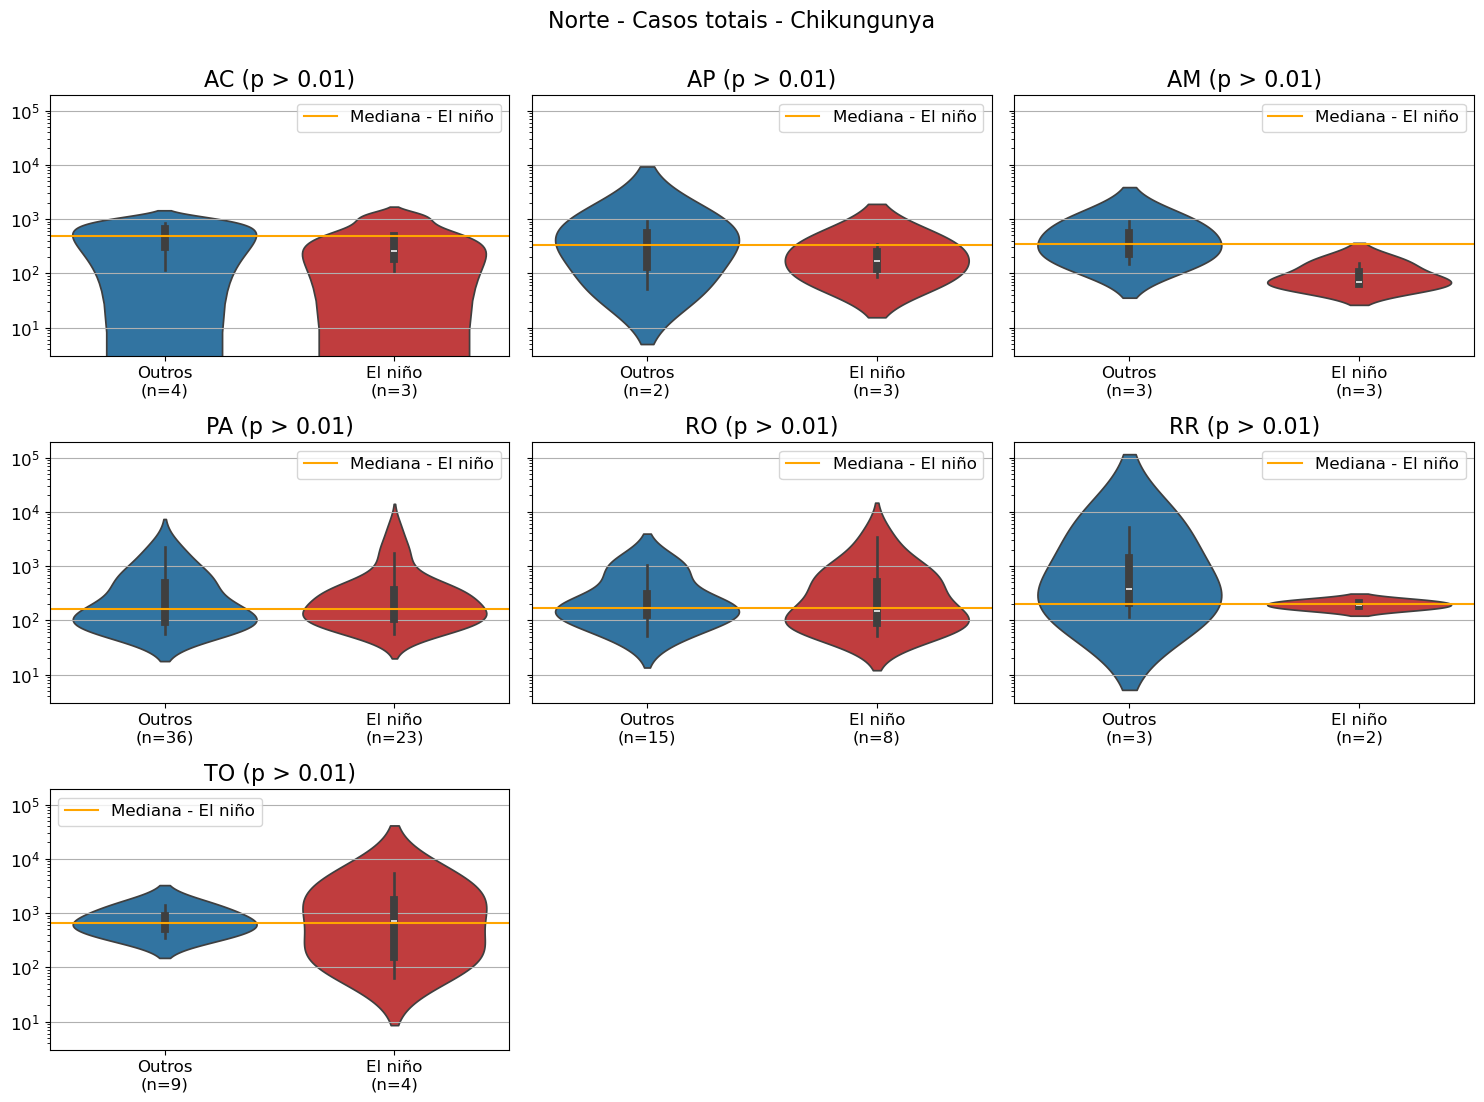

In [23]:
state = [
    "AC",
    "AP",
    "AM",
    "PA",
    "RO",
    "RR",
    "TO"
]

for col in ['peak_week', 'R0', 'total_cases']:

    if col == 'peak_week':
        label = 'semana de pico'

    elif col == 'R0': 
        label = 'R0'

    elif col == 'total_cases': 
        label = 'Casos totais'

    _, ax = plt.subplots(3,3, figsize = (15,11), sharey=True)

    axs = ax.ravel()

    for st, ax in zip(state, axs): 

        plot_violin_by_state(ax, 
            df_pars,
            state = st,
            column = col,
            group_col = 'cenario',
            group_a = 'Outros',
            group_b = 'El niño',
            xlabel='',
            ylabel='',
            palette=['tab:blue', 'tab:red'],
            add_median_line=True,
        )

    axs[-2].axis('off')
    axs[-1].axis('off')

    plt.suptitle(f'Norte - {label} - {doenca}', y = 1)
    plt.tight_layout()
    plt.savefig(f'figures/Norte_{label.lower().replace(" ", "_")}_{doenca.lower().replace(" ", "_")}.png', dpi = 300, bbox_inches ='tight')
    plt.show()